In [1]:
!git clone https://github.com/clayton-h-costa/pv_fault_dataset.git

Cloning into 'pv_fault_dataset'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 24 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 26.69 MiB | 17.48 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
import warnings
warnings.filterwarnings('ignore')

# Set ggplot style
plt.style.use('ggplot')
sns.set_palette("Set2")

In [4]:
# Load the dataset
elec_data = loadmat('pv_fault_dataset/dataset_elec.mat')
amb_data = loadmat('pv_fault_dataset/dataset_amb.mat')

# Extract variables
vdc1 = elec_data['vdc1'].flatten()
vdc2 = elec_data['vdc2'].flatten()
idc1 = elec_data['idc1'].flatten()
idc2 = elec_data['idc2'].flatten()

irr = amb_data['irr'].flatten()
pvt = amb_data['pvt'].flatten()
f_nv = amb_data['f_nv'].flatten()

# Create a DataFrame for easier analysis
df = pd.DataFrame({
    'vdc1': vdc1,
    'vdc2': vdc2,
    'idc1': idc1,
    'idc2': idc2,
    'irradiance': irr,
    'temperature': pvt,
    'fault_label': f_nv
})

In [5]:
# Add calculated columns
df['power_string1'] = df['vdc1'] * df['idc1']
df['power_string2'] = df['vdc2'] * df['idc2']
df['total_power'] = df['power_string1'] + df['power_string2']
df['voltage_ratio'] = df['vdc1'] / df['vdc2']
df['current_ratio'] = df['idc1'] / df['idc2']

print(f"Dataset shape: {df.shape}")
print(f"Number of samples: {len(df)}")

# Create fault name mapping
fault_names = {
    0: 'Normal Operation',
    1: 'Short-Circuit',
    2: 'Degradation',
    3: 'Open Circuit',
    4: 'Shadowing'
}

# Add fault name column
df['fault_name'] = df['fault_label'].map(fault_names)

Dataset shape: (1373798, 12)
Number of samples: 1373798


In [ ]:
# Remove degradation
df = df[df['fault_label'] != 2].copy()

In [ ]:
# View portion of the dataset
df.head()

,vdc1,vdc2,idc1,idc2,irradiance,temperature,fault_label,power_string1,power_string2,total_power,voltage_ratio,current_ratio,fault_name
0,0.7143,0.5550,0.0608,0.0073,1.3729,2.3816,0,0.043429,0.004052,0.047481,1.287027,8.328767,Normal Operation
1,0.6944,0.5427,0.0615,0.0064,1.3604,2.3816,0,0.042706,0.003473,0.046179,1.279528,9.609375,Normal Operation
2,0.7110,0.5583,0.0646,0.0067,1.5118,2.3883,0,0.045931,0.003741,0.049671,1.273509,9.641791,Normal Operation
3,0.6991,0.5465,0.0628,0.0067,1.5534,2.3920,0,0.043903,0.003662,0.047565,1.279231,9.373134,Normal Operation
4,0.7035,0.5553,0.0606,0.0076,1.4355,2.3920,0,0.042632,0.004220,0.046852,1.266883,7.973684,Normal Operation


In [ ]:
# Show dataset summary
print(df.describe())

               vdc1          vdc2          idc1          idc2    irradiance  \
count  1.363427e+06  1.363427e+06  1.363427e+06  1.363427e+06  1.363427e+06   
mean   1.341845e+02  1.339205e+02  2.227183e+00  1.953051e+00  2.524788e+02   
std    1.364277e+02  1.369347e+02  3.150673e+00  2.999955e+00  3.494774e+02   
min    3.799000e-01  3.164000e-01  4.180000e-02  4.600000e-03 -3.810000e-02   
25%    8.862000e-01  8.799000e-01  6.850000e-02  1.250000e-02  1.288800e+00   
50%    3.425490e+01  3.680710e+01  1.133000e-01  4.390000e-02  1.669400e+00   
75%    2.732050e+02  2.721470e+02  4.931650e+00  3.926900e+00  5.767385e+02   
max    3.639740e+02  3.687490e+02  9.654900e+00  9.498700e+00  1.085920e+03   

        temperature   fault_label  power_string1  power_string2   total_power  \
count  1.363427e+06  1.363427e+06   1.363427e+06   1.363427e+06  1.363427e+06   
mean   2.257442e+01  5.705938e-01   5.912309e+02   5.245828e+02  1.115814e+03   
std    1.409529e+01  1.389368e+00   8.504158e

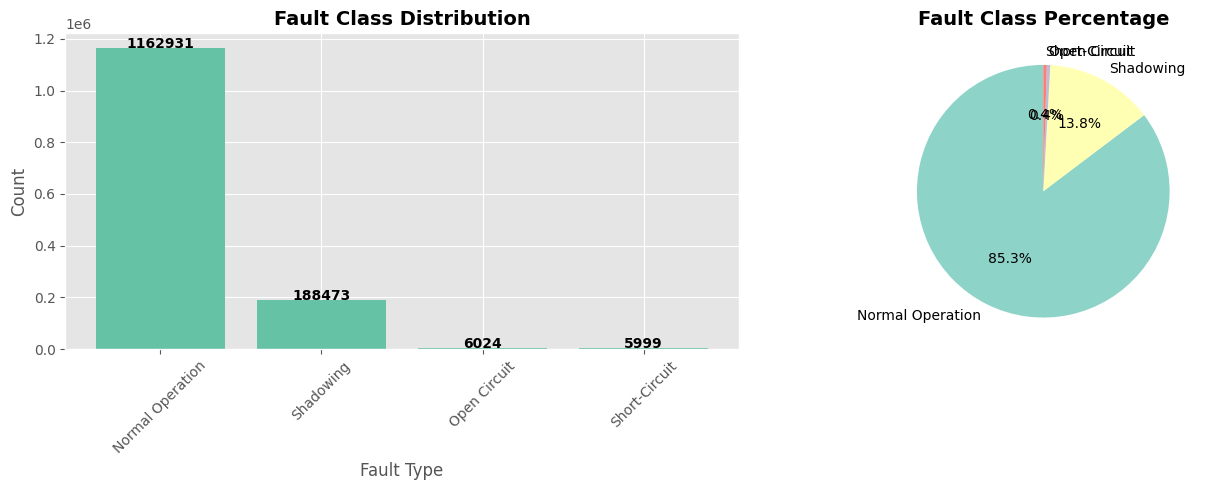


Fault Distribution Details:
Normal Operation: 1162931 samples (85.29%)
Short-Circuit: 5999 samples (0.44%)
Degradation: 0 samples (0.00%)
Open Circuit: 6024 samples (0.44%)
Shadowing: 188473 samples (13.82%)


In [9]:
# Fault Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
fault_counts = df['fault_name'].value_counts()
axes[0].bar(fault_counts.index, fault_counts.values)
axes[0].set_title('Fault Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fault Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(fault_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fault_counts.values, labels=fault_counts.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette("Set3"))
axes[1].set_title('Fault Class Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nFault Distribution Details:")
for fault_id, fault_name in fault_names.items():
    count = len(df[df['fault_label'] == fault_id])
    percentage = (count / len(df)) * 100
    print(f"{fault_name}: {count} samples ({percentage:.2f}%)")

The dataset is relatively balanced; therefore stratified splitting will be used, and relevant class imbalance techniques such as class weights should be used.

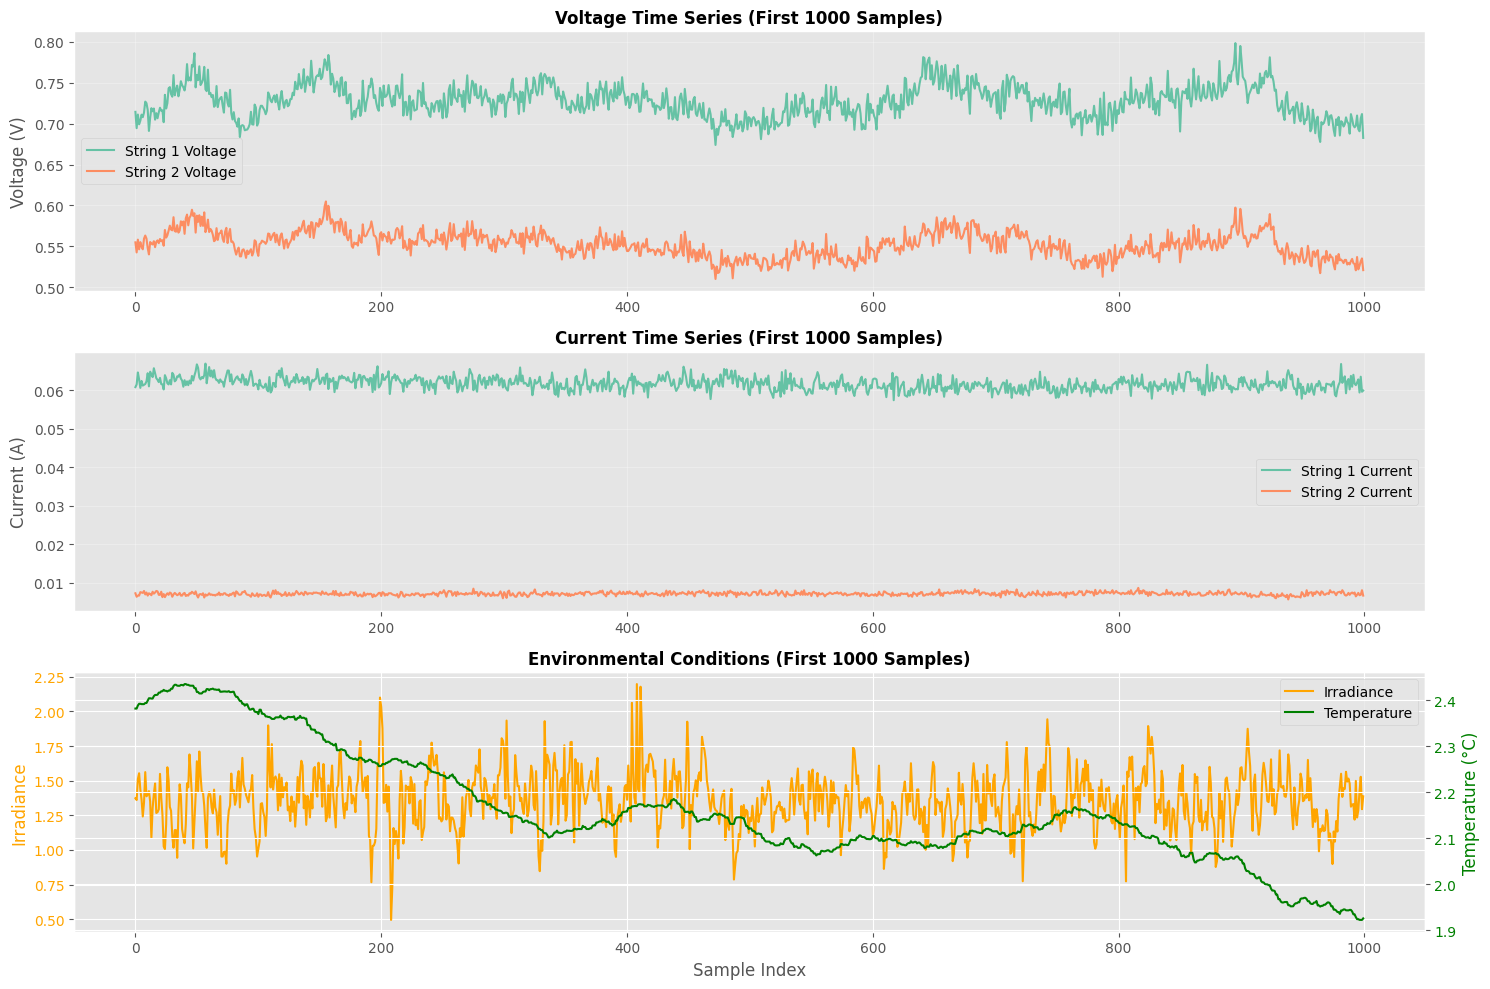

In [10]:
# Time Series Overview (First 1000 samples)
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Voltage time series
axes[0].plot(df['vdc1'].values[:1000], label='String 1 Voltage', linewidth=1.5)
axes[0].plot(df['vdc2'].values[:1000], label='String 2 Voltage', linewidth=1.5)
axes[0].set_title('Voltage Time Series (First 1000 Samples)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Voltage (V)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Current time series
axes[1].plot(df['idc1'].values[:1000], label='String 1 Current', linewidth=1.5)
axes[1].plot(df['idc2'].values[:1000], label='String 2 Current', linewidth=1.5)
axes[1].set_title('Current Time Series (First 1000 Samples)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Current (A)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Environmental time series
ax3 = axes[2]
ax3.plot(df['irradiance'].values[:1000], label='Irradiance', color='orange', linewidth=1.5)
ax3.set_ylabel('Irradiance', color='orange')
ax3.tick_params(axis='y', labelcolor='orange')

ax3_2 = ax3.twinx()
ax3_2.plot(df['temperature'].values[:1000], label='Temperature', color='green', linewidth=1.5)
ax3_2.set_ylabel('Temperature (°C)', color='green')
ax3_2.tick_params(axis='y', labelcolor='green')

axes[2].set_title('Environmental Conditions (First 1000 Samples)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Sample Index')

# Combine legends
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_2.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

In [11]:
# Check for null values
df.isna().sum()

,0
vdc1,0
vdc2,0
idc1,0
idc2,0
irradiance,0
temperature,0
fault_label,0
power_string1,0
power_string2,0
total_power,0


In [12]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [13]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1363427 entries, 0 to 1373797
Data columns (total 13 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   vdc1           1363427 non-null  float64
 1   vdc2           1363427 non-null  float64
 2   idc1           1363427 non-null  float64
 3   idc2           1363427 non-null  float64
 4   irradiance     1363427 non-null  float64
 5   temperature    1363427 non-null  float64
 6   fault_label    1363427 non-null  uint8  
 7   power_string1  1363427 non-null  float64
 8   power_string2  1363427 non-null  float64
 9   total_power    1363427 non-null  float64
 10  voltage_ratio  1363427 non-null  float64
 11  current_ratio  1363427 non-null  float64
 12  fault_name     1363427 non-null  object 
dtypes: float64(11), object(1), uint8(1)
memory usage: 136.5+ MB


In [14]:
# Dataset dimensions
df.shape

(1363427, 13)

In [15]:
# Get all value counts for objects to check for structural errors
for column in df.columns:
  if df[column].dtype == 'object':
    print(f"{column}:")
    print(df[column].value_counts())

fault_name:
fault_name
Normal Operation    1162931
Shadowing            188473
Open Circuit           6024
Short-Circuit          5999
Name: count, dtype: int64


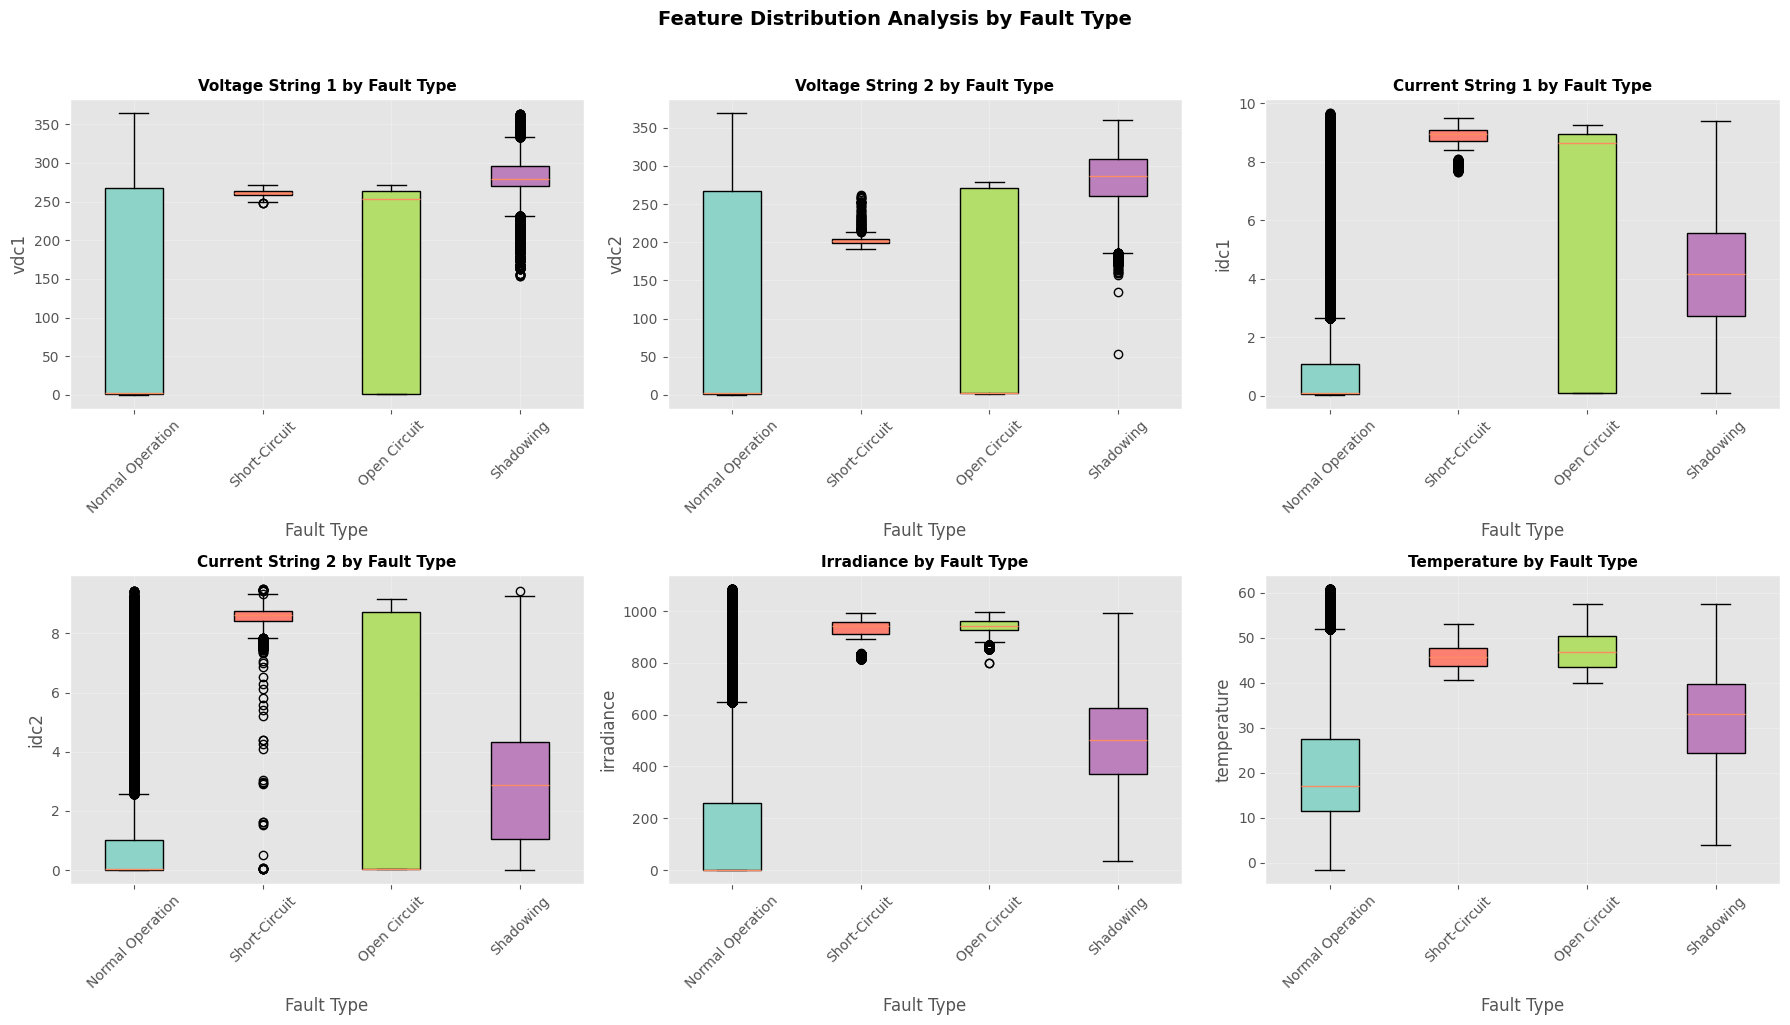

In [16]:
# Feature Distribution by Fault Type
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

features = ['vdc1', 'vdc2', 'idc1', 'idc2', 'irradiance', 'temperature']
titles = ['Voltage String 1', 'Voltage String 2', 'Current String 1',
          'Current String 2', 'Irradiance', 'Temperature']

for idx, (feature, title) in enumerate(zip(features, titles)):
    # Create boxplot
    bp = axes[idx].boxplot([df[df['fault_label'] == fault_id][feature].values
                           for fault_id in sorted(df['fault_label'].unique())],
                          patch_artist=True,
                          labels=[fault_names[i] for i in sorted(df['fault_label'].unique())])

    # Color the boxes
    colors = plt.cm.Set3(np.linspace(0, 1, 5))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    axes[idx].set_title(f'{title} by Fault Type', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Fault Type')
    axes[idx].set_ylabel(feature)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Feature Distribution Analysis by Fault Type', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

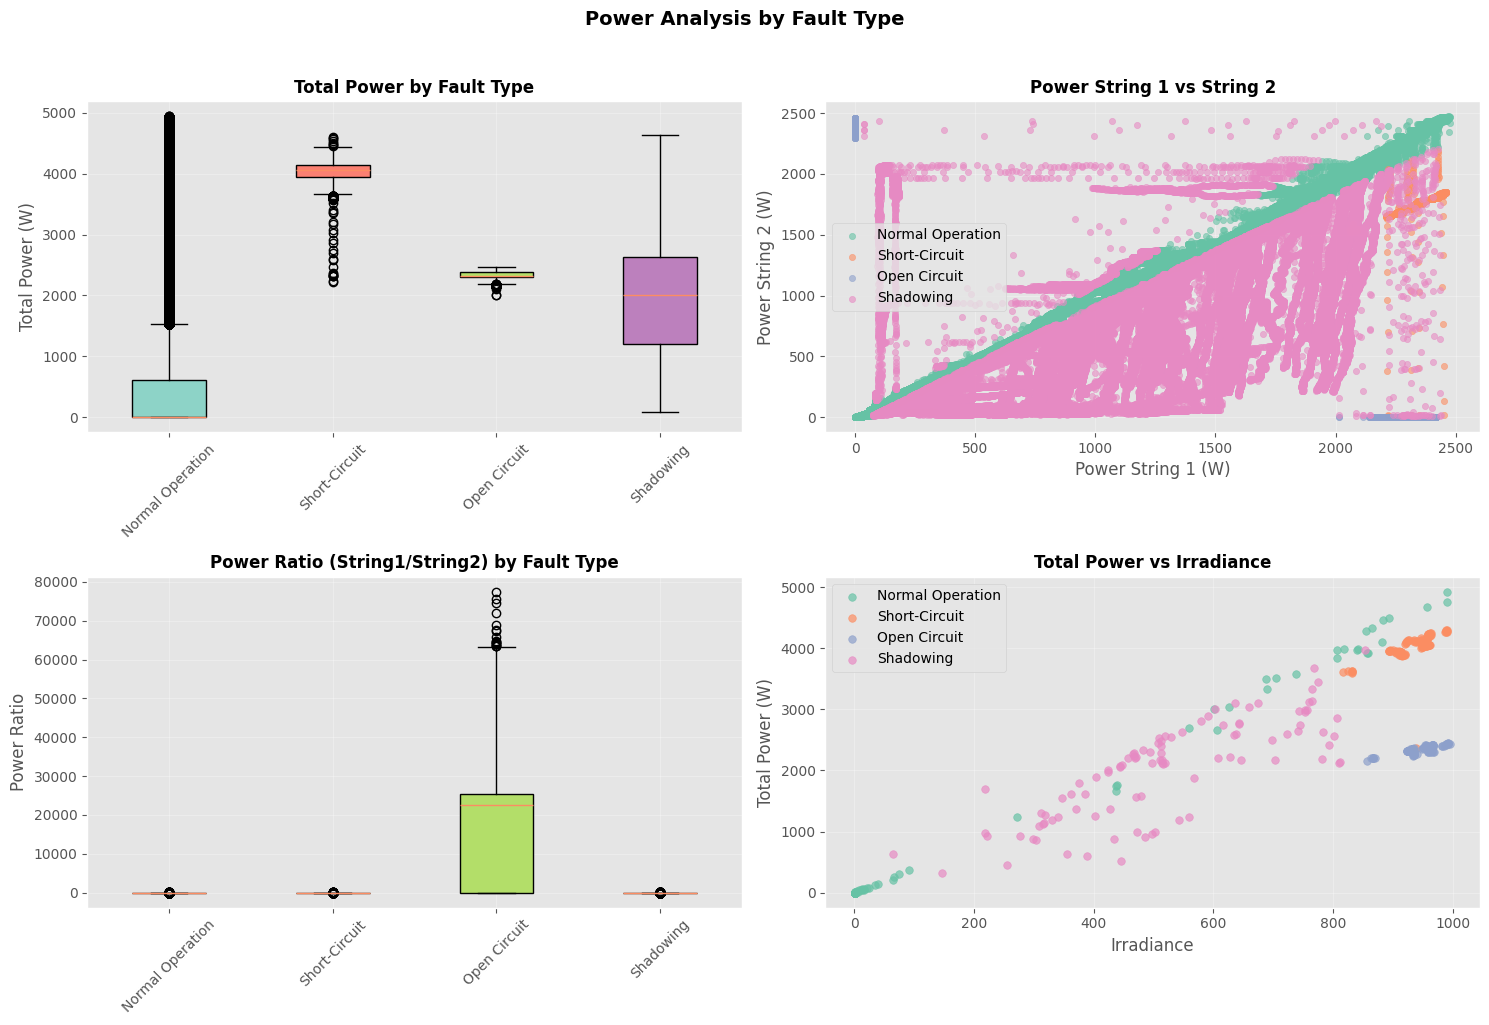

In [18]:
# Power Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

## Total Power by Fault Type
bp1 = axes[0,0].boxplot([df[df['fault_label'] == fault_id]['total_power'].values
                        for fault_id in sorted(df['fault_label'].unique())],
                       patch_artist=True,
                       labels=[fault_names[i] for i in sorted(df['fault_label'].unique())])
colors = plt.cm.Set3(np.linspace(0, 1, 5))
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
axes[0,0].set_title('Total Power by Fault Type', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Total Power (W)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

## Power String 1 vs String 2
for fault_id in sorted(df['fault_label'].unique()):
    fault_data = df[df['fault_label'] == fault_id]
    axes[0,1].scatter(fault_data['power_string1'], fault_data['power_string2'],
                     label=fault_names[fault_id], alpha=0.6, s=20)
axes[0,1].set_title('Power String 1 vs String 2', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Power String 1 (W)')
axes[0,1].set_ylabel('Power String 2 (W)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

## Power Ratio by Fault Type
df['power_ratio'] = df['power_string1'] / df['power_string2']
bp3 = axes[1,0].boxplot([df[df['fault_label'] == fault_id]['power_ratio'].values
                        for fault_id in sorted(df['fault_label'].unique())],
                       patch_artist=True,
                       labels=[fault_names[i] for i in sorted(df['fault_label'].unique())])
for patch, color in zip(bp3['boxes'], colors):
    patch.set_facecolor(color)
axes[1,0].set_title('Power Ratio (String1/String2) by Fault Type', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Power Ratio')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

## Power vs Irradiance
sample_df = df.groupby('fault_label').apply(lambda x: x.sample(min(100, len(x)))).reset_index(drop=True)
for fault_id in sorted(sample_df['fault_label'].unique()):
    fault_data = sample_df[sample_df['fault_label'] == fault_id]
    axes[1,1].scatter(fault_data['irradiance'], fault_data['total_power'],
                     label=fault_names[fault_id], alpha=0.7, s=30)
axes[1,1].set_title('Total Power vs Irradiance', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Irradiance')
axes[1,1].set_ylabel('Total Power (W)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Power Analysis by Fault Type', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Few outliers detected but retained as they may represent real fault behaviour.

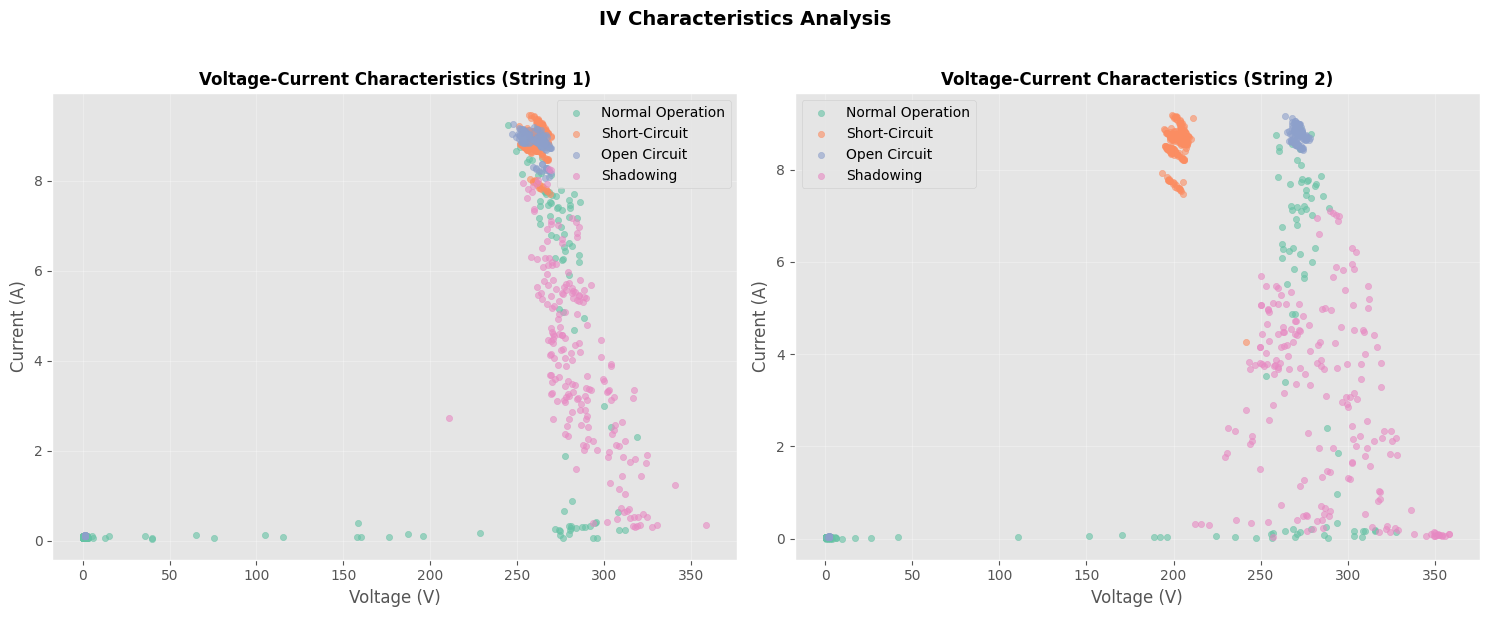

In [19]:
# Voltage-Current Characteristics
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# String 1
for fault_id in sorted(df['fault_label'].unique()):
    fault_data = df[df['fault_label'] == fault_id].sample(min(200, len(df[df['fault_label'] == fault_id])))
    axes[0].scatter(fault_data['vdc1'], fault_data['idc1'],
                   label=fault_names[fault_id], alpha=0.6, s=20)
axes[0].set_title('Voltage-Current Characteristics (String 1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Voltage (V)')
axes[0].set_ylabel('Current (A)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# String 2
for fault_id in sorted(df['fault_label'].unique()):
    fault_data = df[df['fault_label'] == fault_id].sample(min(200, len(df[df['fault_label'] == fault_id])))
    axes[1].scatter(fault_data['vdc2'], fault_data['idc2'],
                   label=fault_names[fault_id], alpha=0.6, s=20)
axes[1].set_title('Voltage-Current Characteristics (String 2)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Voltage (V)')
axes[1].set_ylabel('Current (A)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('IV Characteristics Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

                    vdc1                            vdc2                  \
                    mean     std     min     max    mean     std     min   
Normal Operation  109.21  131.70    0.38  363.97  108.94  131.53    0.32   
Short-Circuit     260.93    4.16  247.62  271.35  202.28    5.13  191.56   
Open Circuit      157.72  126.89    0.69  271.60  109.19  131.82    0.79   
Shadowing         283.50   20.91  154.29  362.89  286.67   31.46   53.41   

                          idc1        ...  idc2       total_power           \
                     max  mean   std  ...   min   max        mean      std   
Normal Operation  368.75  1.87  3.15  ...  0.00  9.43      962.20  1679.67   
Short-Circuit     261.18  8.84  0.38  ...  0.05  9.50     4028.25   201.81   
Open Circuit      279.36  5.37  4.28  ...  0.03  9.17     2333.48    69.95   
Shadowing         360.11  4.14  2.00  ...  0.02  9.44     1932.02   923.88   

                                   irradiance         temperature         

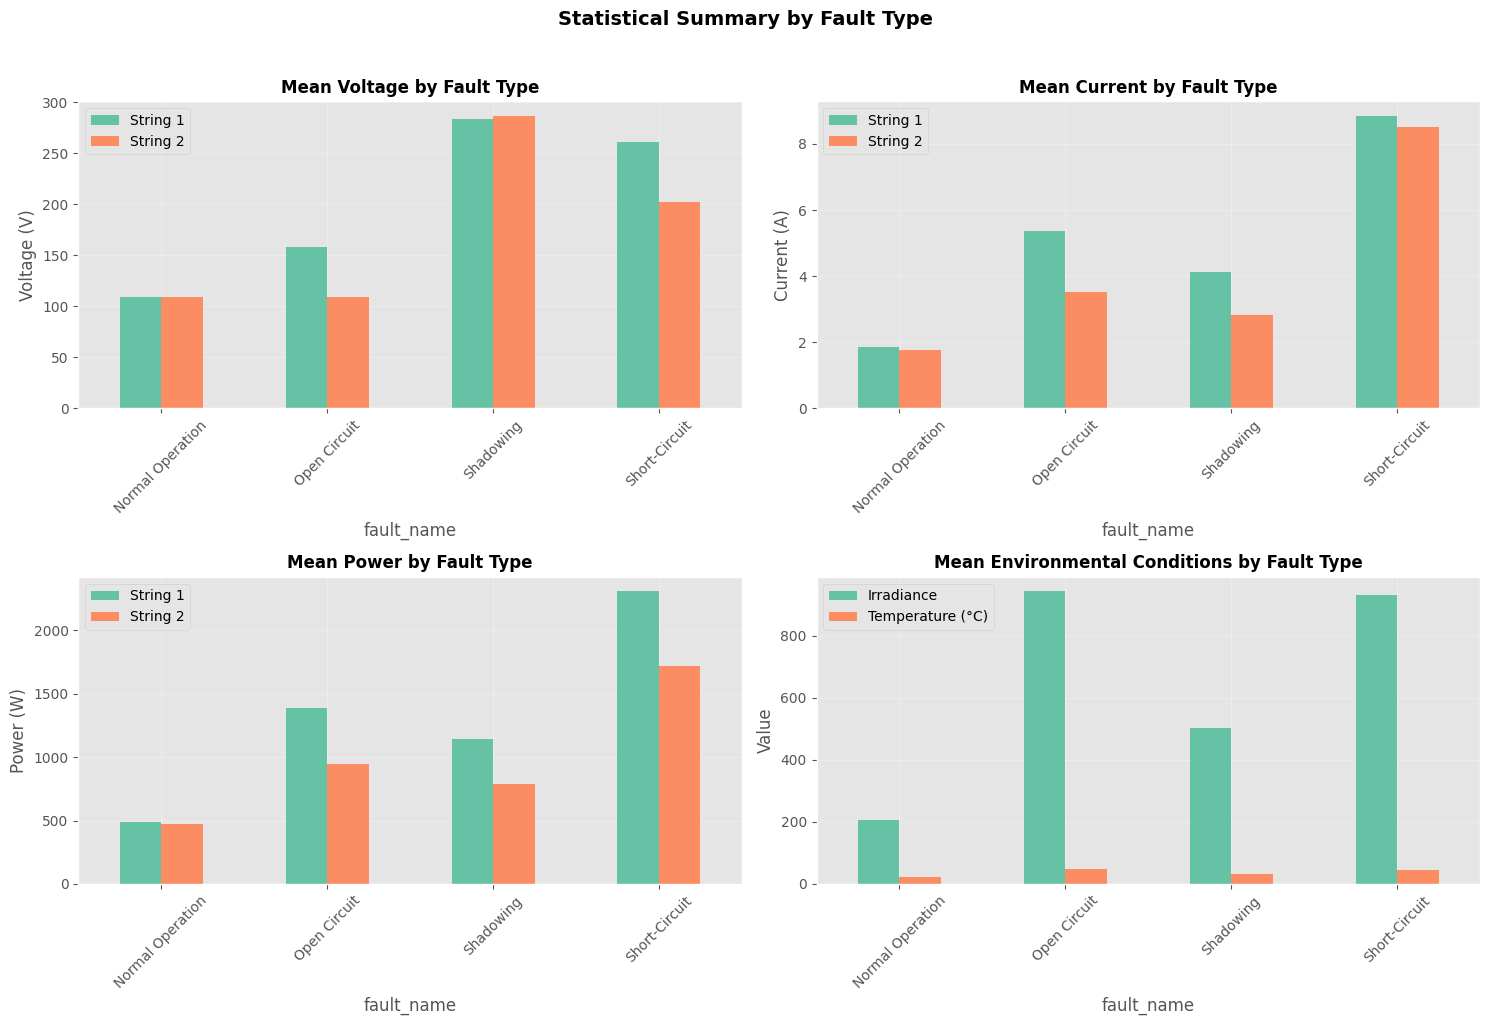

In [20]:
# Statistical Summary by Fault Type

# Group by fault and calculate statistics
fault_stats = df.groupby('fault_label').agg({
    'vdc1': ['mean', 'std', 'min', 'max'],
    'vdc2': ['mean', 'std', 'min', 'max'],
    'idc1': ['mean', 'std', 'min', 'max'],
    'idc2': ['mean', 'std', 'min', 'max'],
    'total_power': ['mean', 'std', 'min', 'max'],
    'irradiance': ['mean', 'std'],
    'temperature': ['mean', 'std']
}).round(2)

# Rename index with fault names
fault_stats.index = [fault_names[i] for i in fault_stats.index]

print(fault_stats)

# Visualize key statistics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Mean voltage by fault
mean_voltages = df.groupby('fault_name')[['vdc1', 'vdc2']].mean()
mean_voltages.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Mean Voltage by Fault Type', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Voltage (V)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend(['String 1', 'String 2'])
axes[0,0].grid(True, alpha=0.3)

# Mean current by fault
mean_currents = df.groupby('fault_name')[['idc1', 'idc2']].mean()
mean_currents.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Mean Current by Fault Type', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Current (A)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend(['String 1', 'String 2'])
axes[0,1].grid(True, alpha=0.3)

# Mean power by fault
mean_power = df.groupby('fault_name')[['power_string1', 'power_string2']].mean()
mean_power.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Mean Power by Fault Type', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Power (W)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(['String 1', 'String 2'])
axes[1,0].grid(True, alpha=0.3)

# Environmental conditions by fault
env_stats = df.groupby('fault_name')[['irradiance', 'temperature']].mean()
env_stats.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Mean Environmental Conditions by Fault Type', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Value')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend(['Irradiance', 'Temperature (°C)'])
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Statistical Summary by Fault Type', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

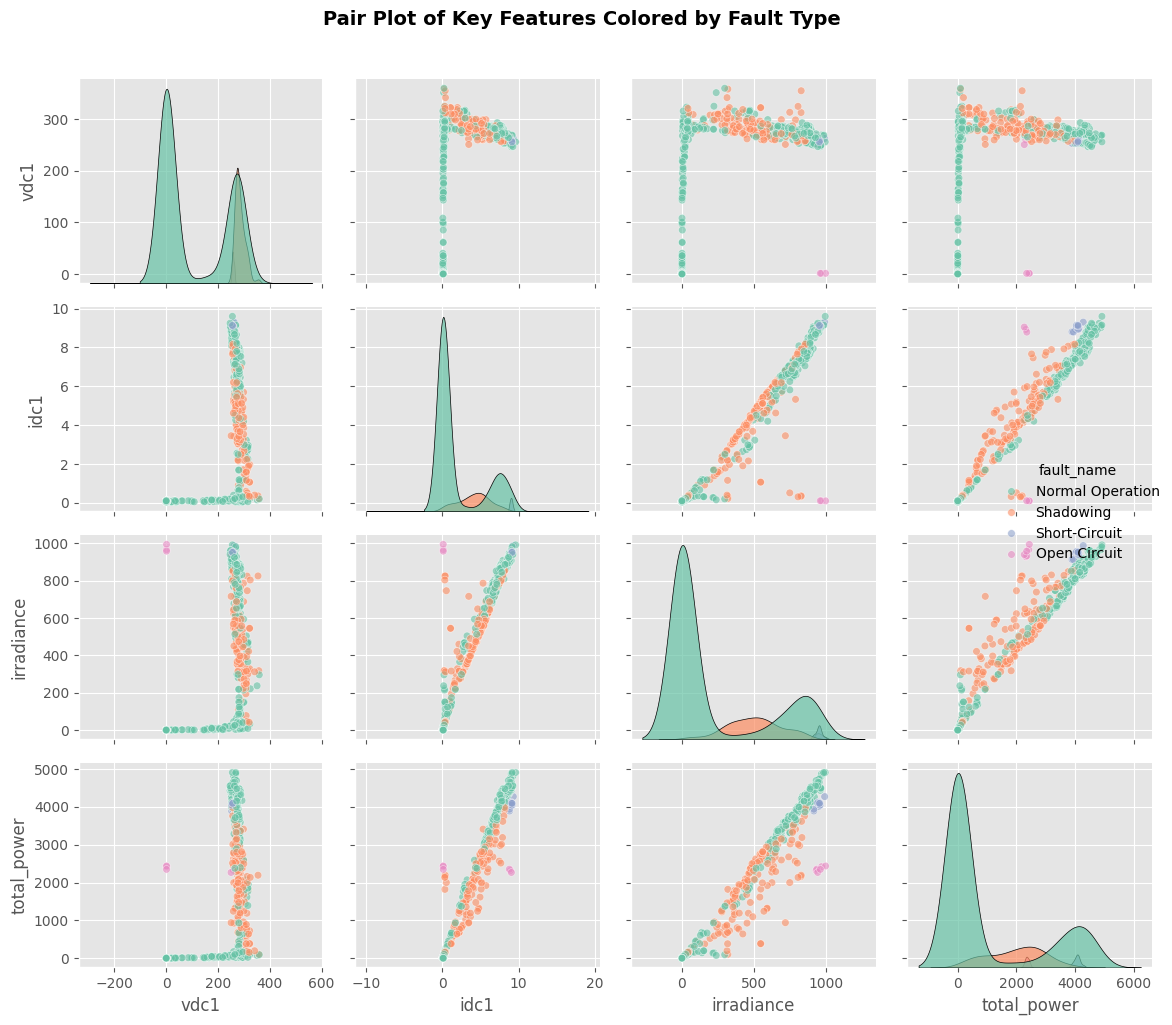

In [21]:
# Pair Plot for Selected Features

# Sample data for pair plot to avoid overcrowding
sample_size = min(1000, len(df))
sample_df = df.sample(sample_size, random_state=42)

# Select features for pair plot
pair_plot_features = ['vdc1', 'idc1', 'irradiance', 'total_power', 'fault_name']

fig = sns.pairplot(sample_df[pair_plot_features],
                   hue='fault_name',
                   palette='Set2',
                   plot_kws={'alpha': 0.6, 's': 30},
                   diag_kws={'alpha': 0.7, 'edgecolor': 'black'})

fig.fig.suptitle('Pair Plot of Key Features Colored by Fault Type',
                 y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

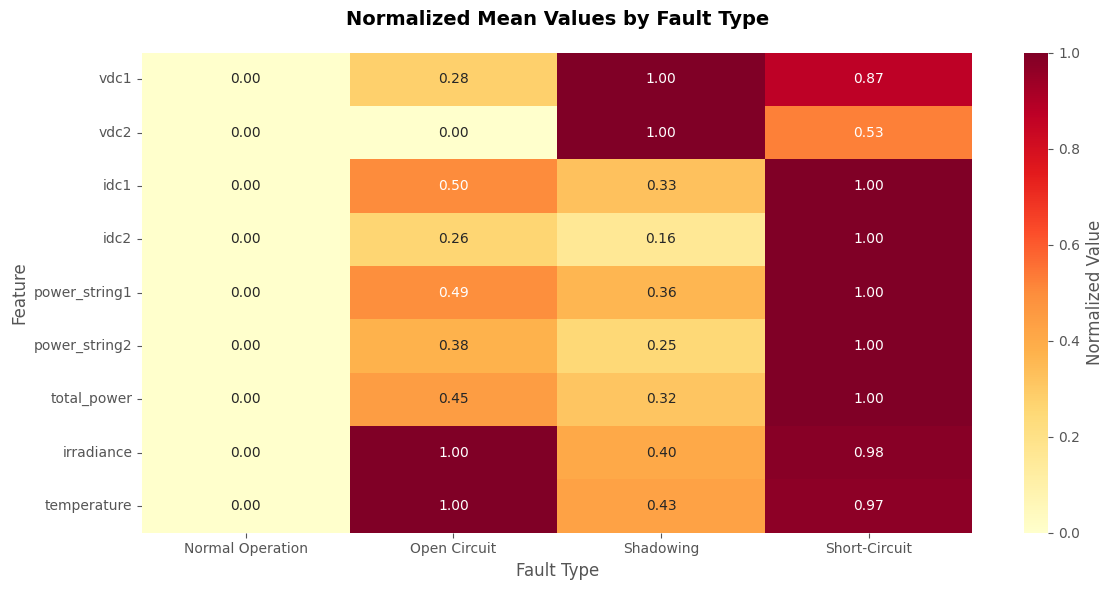

In [22]:
# Heatmap of Fault Patterns

# Calculate mean values for each fault type
fault_means = df.groupby('fault_name').mean()[['vdc1', 'vdc2', 'idc1', 'idc2',
                                               'power_string1', 'power_string2',
                                               'total_power', 'irradiance', 'temperature']]

# Normalize for better visualization
fault_means_normalized = fault_means.copy()
for col in fault_means.columns:
    fault_means_normalized[col] = (fault_means[col] - fault_means[col].min()) / \
                                  (fault_means[col].max() - fault_means[col].min())

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(fault_means_normalized.T, annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': 'Normalized Value'}, ax=ax)
ax.set_title('Normalized Mean Values by Fault Type', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Fault Type')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

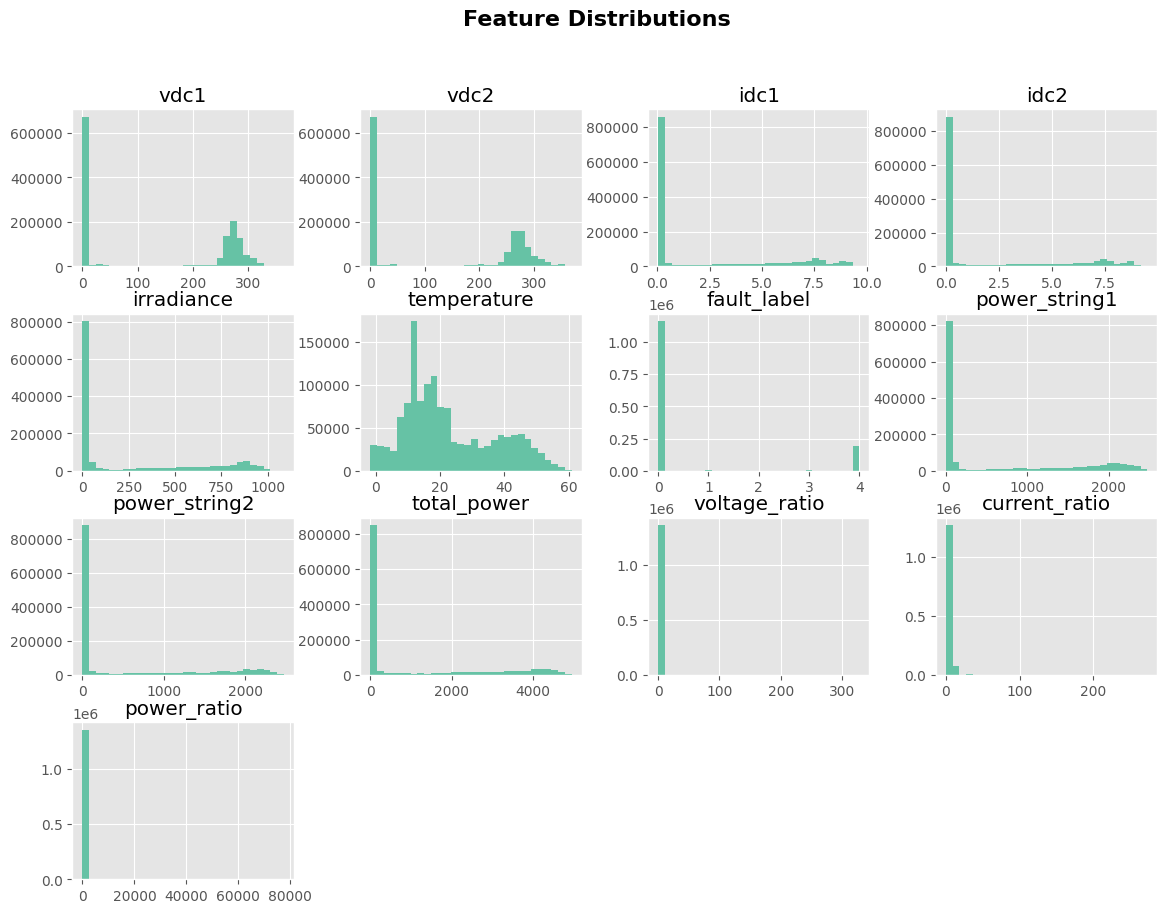

In [24]:
# Check skewness and distributions
df.hist(figsize=(14,10), bins=30)
plt.suptitle("Feature Distributions", fontsize=16, fontweight='bold')
plt.show()

In [ ]:
# Correlation with target for leakage check
corr_with_target = df.corr(numeric_only=True)['fault_label'].sort_values(ascending=False)
print("Correlation with Fault Label:")
print(corr_with_target)

Correlation with Fault Label:
fault_label      1.000000
vdc2             0.443806
vdc1             0.440158
irradiance       0.310123
temperature      0.285224
power_string1    0.275213
idc1             0.257753
total_power      0.211127
power_string2    0.137986
idc2             0.128768
current_ratio    0.094493
voltage_ratio    0.089183
power_ratio      0.088820
Name: fault_label, dtype: float64


No feature shows near-perfect correlation with the target variable.
This confirms that there is no target leakage and the dataset is suitable for machine learning.